In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import factorial

In [101]:
data = pd.read_csv("hist_week3_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data1 = pd.read_csv("hist_10ms.txt",sep='\t', header=0, names=["x", "y"])
data2 = pd.read_csv("hist_18mswait_width20.txt",sep='\t', header=0, names=["x", "y"])
data1['x'] = round(data1['x'])
data['x'] = round(data['x'])
data2['x'] = round(data2['x'])

In [68]:
data_470o = pd.read_csv("470o_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_600o = pd.read_csv("600o_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_760o = pd.read_csv("new_760o_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_1ko = pd.read_csv("1ko_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_1p6ko = pd.read_csv("1ko_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_2ko = pd.read_csv("2.2ko_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_2p5ko = pd.read_csv("2.5ko_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_3ko = pd.read_csv("3.3ko_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)

data_470o['x'] = round(data_470o['x'])
data_600o['x'] = round(data_600o['x'])
data_760o['x'] = round(data_760o['x'])
data_1ko['x'] = round(data_1ko['x'])
data_1p6ko['x'] = round(data_1p6ko['x'])
data_2ko['x'] = round(data_2ko['x'])
data_3ko['x'] = round(data_3ko['x'])
data_2p5ko['x'] = round(data_2p5ko['x'])

In [26]:
def weight_avg(x, y):
    return np.sum(x * y) / np.sum(y)

Text(0, 0.5, 'Mean Count')

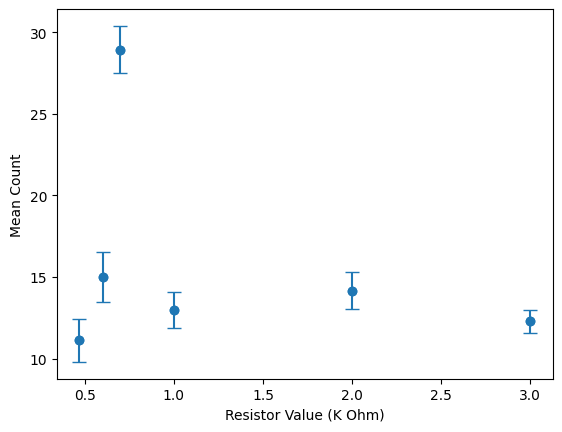

In [56]:
resistors = np.array([.470, .600,.700, 1, 2, 3])
counts = np.array([weight_avg(data_470o['x'], data_470o['y']), weight_avg(data_600o['x'], data_600o['y']), weight_avg(data_760o['x'], data_760o['y']), weight_avg(data_1ko['x'], data_1ko['y']), weight_avg(data_2ko['x'], data_2ko['y']), weight_avg(data_3ko['x'], data_3ko['y'])])
counts_std = np.array([data_470o['y'].std(), data_600o['y'].std(), data_760o['y'].std(), data_1ko['y'].std(), data_2ko['y'].std(), data_3ko['y'].std()])
plt.scatter(resistors, counts)
plt.errorbar(resistors, counts, yerr=counts_std/np.sqrt(len(counts)), fmt='o', capsize=5)
plt.xlabel('Resistor Value (K Ohm)')
plt.ylabel('Mean Count')

In [19]:
data_760o['y'].mean()

np.float64(4.6)

Text(0, 0.5, 'Mean Count')

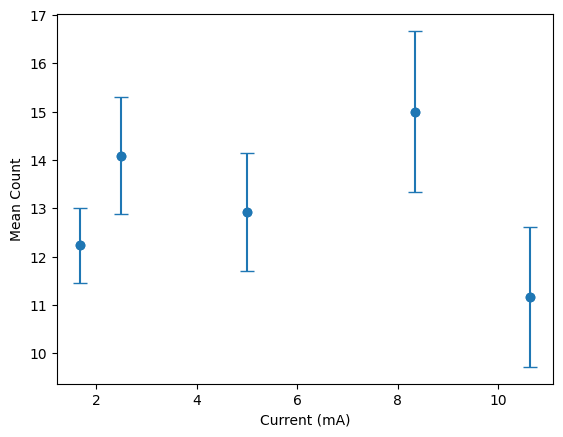

In [32]:
current = 5 / (resistors * 1000) * 1000 
plt.scatter(current, counts)
plt.errorbar(current, counts, yerr=counts_std/np.sqrt(len(counts)), fmt='o', capsize=5)
plt.xlabel('Current (mA)')
plt.ylabel('Mean Count')

Text(0, 0.5, 'Occurrencs ')

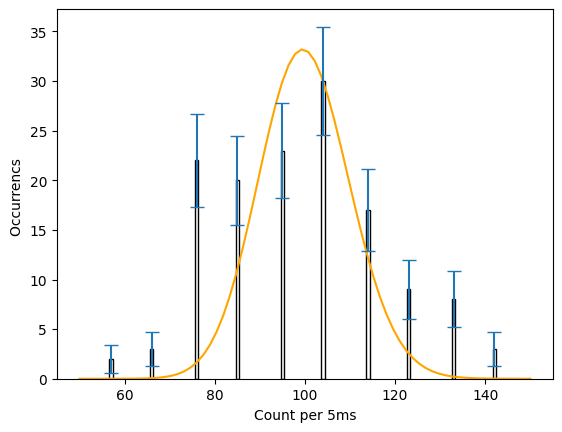

In [110]:
def poss(n,l,a):
    return (l*a)**n*np.exp(-l)/factorial(n)
data1=data2
params, _ = curve_fit(poss, data1["x"],data1["y"],p0=[70,1])
count=np.linspace(50, 150, 70)
plt.plot(count,poss(count,params[0],params[1]),color='orange')
plt.errorbar(data1["x"], data1["y"], yerr=np.sqrt(data1["y"]),fmt='none',ecolor='tab:blue', capsize=5)
plt.bar(data1["x"], data1["y"],align='center',edgecolor='black',width=0.75,color='white')
plt.xlabel("Count per 5ms")
plt.ylabel("Occurrencs ")

Text(0, 0.5, 'Occurrencs ')

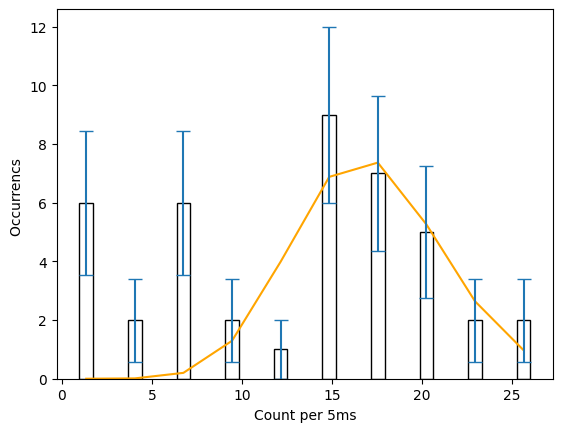

In [ ]:
params, _ = curve_fit(poss, data_1ko["x"],data_1ko["y"],p0=[10,1])


plt.plot(data_1ko["x"],poss(data_1ko["x"],params[0],params[1]),color='orange')
plt.errorbar(data_1ko["x"], data_1ko["y"], yerr=np.sqrt(data_1ko["y"]),fmt='none',ecolor='tab:blue', capsize=5)
plt.bar(data_1ko["x"], data_1ko["y"],align='center',edgecolor='black',width=0.75,color='white')
plt.xlabel("Count per 5ms")
plt.ylabel("Occurrencs ")

In [71]:
def find_p0(data):
    params, pcov = curve_fit(poss, data["x"],data["y"],p0=[np.median(data['x']),1])

    return [params[0],np.sqrt(np.diag(pcov)[0])]



<BarContainer object of 10 artists>

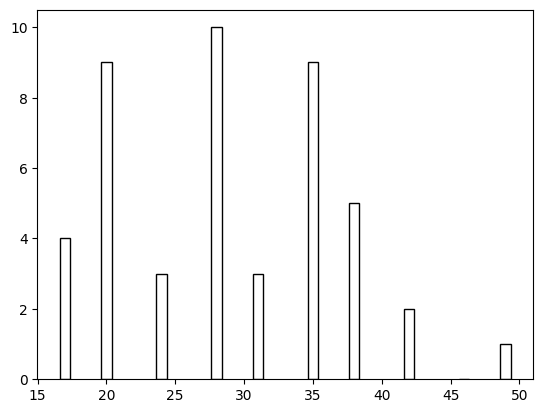

In [50]:
plt.bar(data_760o["x"], data_760o["y"],align='center',edgecolor='black',width=0.75,color='white')

Text(0, 0.5, 'Center from Poisson Fit')

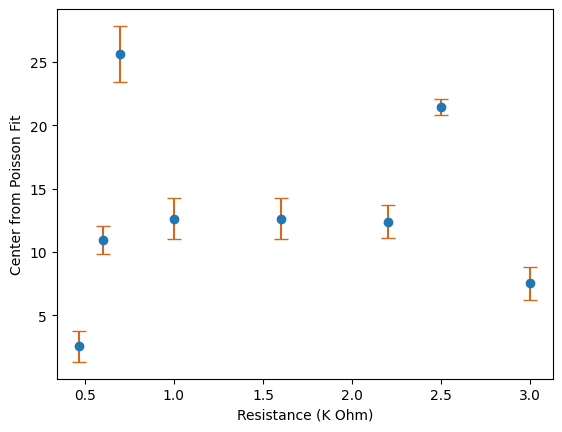

In [80]:
resistors = np.array([.470, .600,.700, 1,1.6, 2.2, 3,2.5])
centers = np.array([find_p0(data_470o)[0], find_p0(data_600o)[0], find_p0(data_760o)[0], find_p0(data_1ko)[0], find_p0(data_1p6ko)[0], find_p0(data_2ko)[0], find_p0(data_3ko)[0],find_p0(data_2p5ko)[0]])
centers_err = np.array([find_p0(data_470o)[1], find_p0(data_600o)[1], find_p0(data_760o)[1], find_p0(data_1ko)[1], find_p0(data_1p6ko)[1], find_p0(data_2ko)[1], find_p0(data_3ko)[1],find_p0(data_2p5ko)[1]])

plt.errorbar(resistors,centers,centers_err,fmt='o',capsize=5,ecolor='chocolate',color='tab:blue')
plt.xlabel("Resistance (K Ohm)")
plt.ylabel("Center from Poisson Fit")

In [65]:
find_p0(data_470o)

[np.float64(2.5607166340624916), np.float64(1.5031963224127645)]